# Open Assignment: Machine Learning

**Program: Digital Technology** 

- Semester: I
- Subject: AI-CR-501/DS-CR-503 Machine Learning 
- Level: Masters In Applied Science 

#### Question 1: Linear Regression

**`Provide your own Python implementation of Linear Regression following the mathematical description provided in the class.`**

**`Write a simple data generator to generate data for age vs height showing transition points where the height increases sharply (see lecture slides).`**

**`Include knot points to model transition points into your feature modelling. Train your model in the synthetic data you have generated.`** 

**`Plot loss curves against training epochs. Plot your model prediction against ground truth data.`**

**`Compare your model output against sklearn implementation of linear regression.`**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERATING AGE AND HEIGHT DATA
np.random.seed(42)

ages = np.random.uniform(1, 18, 200)
heights = np.zeros(200)

# Create height data
for i, age in enumerate(ages):
    base_height = 50 + 5 * age

    # Growth changes after age 10
    height_1 = 3 * max(0, age - 10)

    # Growth changes again after age 15
    height_2 = 7 * max(0, age - 15)

    # Add some random noise
    noise = np.random.normal(0, 2.5)
    heights[i] = base_height + height_1 + height_2 + noise

# 2. FEATURE ENGINEERING
# Knots aligned with the data generation logic
knot1 = 10 
knot2 = 15

# Create the feature matrix
X = np.column_stack([
    np.ones(len(ages)),
    ages,
    np.maximum(0, ages - knot1),
    np.maximum(0, ages - knot2)
])

y = heights.reshape(-1, 1)

# 3. LINEAR REGRESSION FROM SCRATCH 
# Lowered learning rate to prevent exploding gradients and increased epochs
learning_rate = 0.0005 
epochs = 50000

# Start all weights at 0
weights = np.zeros((X.shape[1], 1))

# Store loss after every epoch
loss_history = []

# Gradient descent
for epoch in range(epochs):
    predictions = X.dot(weights)
    error = predictions - y

    # Calculate loss
    loss = (1 / (2 * len(X))) * np.sum(error ** 2)
    loss_history.append(loss)

    # Calculate gradients
    gradients = (1 / len(X)) * X.T.dot(error)
    
    # Update weights
    weights = weights - learning_rate * gradients

Weights learned by sklearn:
[50.63923525  4.91132811  3.26250595  6.48218835]


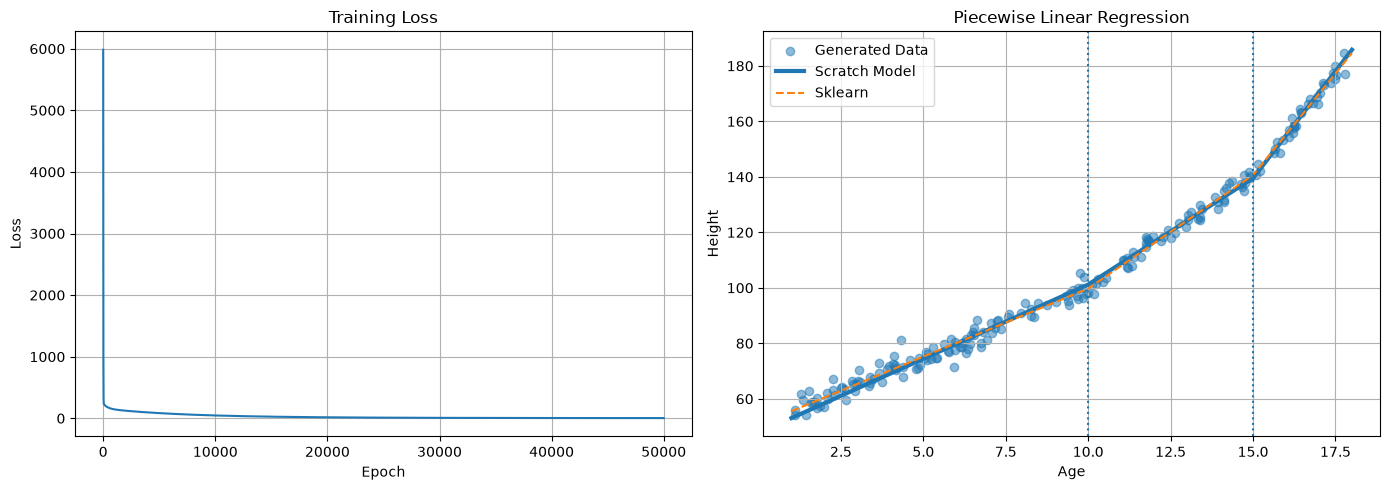

In [2]:
# Compare with sklearn

from sklearn.linear_model import LinearRegression

# We already have a column of 1s in X,
# so we don't need another intercept.
sklearn_model = LinearRegression(fit_intercept=False)

sklearn_model.fit(X, y)

print("Weights learned by sklearn:")
print(sklearn_model.coef_.flatten())


# Create smooth age values for plotting
smooth_ages = np.linspace(1, 18, 500)

# Create the same knot features for smooth_ages
X_smooth = np.column_stack([
    np.ones(len(smooth_ages)),
    smooth_ages,
    np.maximum(0, smooth_ages - knot1),
    np.maximum(0, smooth_ages - knot2)
])

# Predictions from our model
scratch_predictions = X_smooth.dot(weights)

# Predictions from sklearn
sklearn_predictions = sklearn_model.predict(X_smooth)

# PLOTS

plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)


# Data and predictions
plt.subplot(1, 2, 2)

# Original generated data
plt.scatter(
    ages,
    heights,
    alpha=0.5,
    label="Generated Data"
)


# Our model prediction
plt.plot(
    smooth_ages,
    scratch_predictions,
    linewidth=3,
    label="Scratch Model"
)

# Sklearn prediction
plt.plot(
    smooth_ages,
    sklearn_predictions,
    linestyle="--",
    label="Sklearn"
)

# Show the knot points
plt.axvline(
    knot1,
    linestyle=":"
)

plt.axvline(
    knot2,
    linestyle=":"
)

plt.title("Piecewise Linear Regression")
plt.xlabel("Age")
plt.ylabel("Height")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Generate age and height data for question no. 2

In [3]:
import pandas as pd
data_df = pd.DataFrame({
    'Age': ages,
    'Height': heights
})

data_df.to_csv('age_height_data.csv', index=False)
print("Data successfully saved to 'age_height_data.csv'")

Data successfully saved to 'age_height_data.csv'


#### Question 2: Regularization

**Provide your own Python implementation of Ridge Regression and Lasso 
Regression following the mathematical description provided in the class.**

**For the `a. age` vs `height` data and from Q1 and 	`b. cancer dataset` from HTF (Elements of Statistical Learning) book. Apply your Ridge regression and Lasso regression to automatically eliminate features that are not highly relevant. Try this for different values of lambda.

**Compare your model output against sklearn implementation of Ridge and Lasso linear 
regression. Please note that sklearn implementation of both are a bit different from the one described in class. Understand these differences.**

In particular, in our class, we used the following loss function for Ridge regression:
′

whereas, in sklearn, the following loss function is employed:

Change your loss function to the above used within sklearn and re-run your code. 

#### Ridge Regression Implementation

In [4]:
import numpy as np

class RidgeRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value 
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
          
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Compute gradients for the base loss (MSE)
            dw_mse = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_mse = (2 / n_samples) * np.sum(y_predicted - y)

            # Apply the lambda weighting and regularization penalty
            # dw = lambda * dw_mse + (1 - lambda) * 2w
            dw = self.lam * dw_mse + (1 - self.lam) * 2 * self.weights
            
            # db = lambda * db_mse (Bias is not regularized)
            db = self.lam * db_mse

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

#### Lasso Regression Implementation

In [5]:
class LassoRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Factoring the negative sign into (y_predicted - y)
            dw_base = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_base = (2 / n_samples) * np.sum(y_predicted - y)

            # Apply the lambda weighting and the L1 subgradient penalty
            # np.sign() returns -1 if x < 0, 0 if x==0, 1 if x > 0
            dw = self.lam * dw_base + (1 - self.lam) * np.sign(self.weights)
            
            # db = lambda * db_base (Bias is not regularized)
            db = self.lam * db_base

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

**For the a. age vs height data and from Q1 and b. cancer dataset from HTF (Elements of Statistical Learning) book. Apply your Ridge regression and Lasso regression to automatically eliminate features that are not highly relevant. Try this for different values of lamda_value:**

####  Applying Lasso regression on age vs height from Q1

In [6]:
# load the dataset
df = pd.read_csv("age_height_data.csv")

ages = df[['Age']]
heights = df['Height']

# To demonstrate feature elimination, we'll create a rich feature set:
# Fake knots (Knot at 5, Knot at 8, Knot at 12)
# Pure random noise features

np.random.seed(42)
knots = [5, 8, 10, 12, 15]
feature_names = ['Age'] + [f'Knot_{k}' for k in knots] + ['Noise_1', 'Noise_2']

# change features column to a list
X_list = [ages.values]

for k in knots:
    X_list.append(np.maximum(0, ages - k))
X_list.append(np.random.normal(0, 1, len(ages)))
X_list.append(np.random.normal(0, 1, len(ages)))

X = np.column_stack(X_list)
y = heights.values

# Standardizing the features 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std


# Test different lambda values
lambdas = [1.0, 0.99, 0.95, 0.90]
results = {}

for lam in lambdas:
    model = LassoRegression(learning_rate=0.1, lambda_value=lam, n_iterations=5000)
    model.fit(X_scaled, y_scaled)
    # Round to 4 decimal places for clean display
    results[f'λ = {lam}'] = np.round(model.weights, 4)

df_weights = pd.DataFrame(results, index=feature_names)
df_weights.T

,Age,Knot_5,Knot_8,Knot_10,Knot_12,Knot_15,Noise_1,Noise_2
λ = 1.0,0.6451,0.0809,-0.0331,0.2676,-0.0357,0.1292,-0.0004,-0.0016
λ = 0.99,0.6434,0.0699,0.0003,0.2147,0.0008,0.1178,-0.0009,-0.0007
λ = 0.95,0.6235,0.0717,0.0051,0.2165,0.0008,0.1025,0.0027,-0.0011
λ = 0.9,0.5972,0.0754,0.0040,0.2207,0.0076,0.0786,-0.0054,0.0104


##### Explanation

#### Applying Ridge regression on age vs height from Q1

In [7]:
# load the dataset
df = pd.read_csv("age_height_data.csv")

ages = df[['Age']]
heights = df['Height']

# To demonstrate feature elimination, we'll create a rich feature set:
# Fake knots (Knot at 5, Knot at 8, Knot at 12)
# Pure random noise features

np.random.seed(42)
knots = [5, 8, 10, 12, 15]
feature_names = ['Age'] + [f'Knot_{k}' for k in knots] + ['Noise_1', 'Noise_2']

# change features column to a list
X_list = [ages.values]

for k in knots:
    X_list.append(np.maximum(0, ages - k))
    
X_list.append(np.random.normal(0, 1, len(ages)))
X_list.append(np.random.normal(0, 1, len(ages)))

X = np.column_stack(X_list)
y = heights.values

# Standardizing the features 
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y_scaled = (y - y_mean) / y_std


# Test different lambda values
lambdas = [1.0, 0.99, 0.95, 0.90]
results = {}

for lam in lambdas:
    model = RidgeRegression(learning_rate=0.1, lambda_value=lam, n_iterations=5000)
    model.fit(X_scaled, y_scaled)
    # Round to 4 decimal places for clean display
    results[f'λ = {lam}'] = np.round(model.weights, 4)

df_weights = pd.DataFrame(results, index=feature_names)
df_weights.T

,Age,Knot_5,Knot_8,Knot_10,Knot_12,Knot_15,Noise_1,Noise_2
λ = 1.0,0.6451,0.0809,-0.0331,0.2676,-0.0357,0.1292,-0.0004,-0.0016
λ = 0.99,0.5235,0.1895,0.0621,0.1232,0.0326,0.1171,0.0009,-0.0033
λ = 0.95,0.3993,0.2470,0.1320,0.0980,0.0554,0.1008,0.0025,-0.0040
λ = 0.9,0.3424,0.2465,0.1557,0.1116,0.0717,0.0890,0.0037,-0.0029


##### Explanation

#### Prostate cancer data

In [8]:
import pandas as pd

df = pd.read_csv("prostate.csv", sep='\t')
df = df.iloc[:, 1:]
df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783,T
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519,T
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519,T
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519,T
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564,T


#### Applying Lasso Regression this prostate cancer dataset

In [ ]:
# Train/Test Split based on the 'train' column
train_df = df[df['train'] == 'T'].drop(columns=['train'])
test_df = df[df['train'] == 'F'].drop(columns=['train'])

# Extract features and target 
X_train = train_df.drop(columns=['lpsa']).values
y_train = train_df['lpsa'].values

X_test = test_df.drop(columns=['lpsa']).values
y_test = test_df['lpsa'].values

# Standardize the features
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [12]:
# Fit the model 
model = RidgeRegression(learning_rate=0.1, lambda_value=0.9, n_iterations=1000)
model.fit(X_train_scaled, y_train)

#Evaluate Model
y_pred = model.predict(X_test_scaled)
mse = np.mean((y_test - y_pred)**2)

# Map weights back to feature names for readability
feature_names = train_df.drop(columns=['lpsa']).columns
weights_dict = dict(zip(feature_names, np.round(model.weights, 4)))

print("Learned Weights:")
for feature, weight in weights_dict.items():
    print(f"{feature}: {weight}")

print(f"\nBias: {round(model.bias, 4)}")
print(f"Test Mean Squared Error (MSE): {round(mse, 4)}")

Learned Weights:
lcavol: 0.5698
lweight: 0.2801
age: -0.0975
lbph: 0.1954
svi: 0.2737
lcp: -0.121
gleason: 0.0208
pgg45: 0.1859

Bias: 2.4523
Test Mean Squared Error (MSE): 0.4897


**Finding:** 

- The result above indicates that cancer volume (lcavol) and prostate weight (lweight) are the strongest positive predictors of lpsa in this dataset, while the L2 penalty has kept less relevant features (like gleason score) stabilized near zero.